In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score
)


1. LOAD DATA + VISUALIZATION

In [4]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_path = r"C:\Users\DIKSH\OneDrive\Desktop\Projects\Pneumonia detection using DL\chest_xray\train"
val_path   = r"C:\Users\DIKSH\OneDrive\Desktop\Projects\Pneumonia detection using DL\chest_xray\val"
test_path  = r"C:\Users\DIKSH\OneDrive\Desktop\Projects\Pneumonia detection using DL\chest_xray\test"

train_gen = ImageDataGenerator(
        rescale=1/255.,
        shear_range=0.1,
        zoom_range=0.2,
        horizontal_flip=True)

val_gen = ImageDataGenerator(rescale=1/255.)
test_gen = ImageDataGenerator(rescale=1/255.)

train_data = train_gen.flow_from_directory(
        train_path,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        class_mode='binary',
        batch_size=BATCH_SIZE,
        shuffle=True)

val_data = val_gen.flow_from_directory(
        val_path,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        class_mode='binary',
        batch_size=BATCH_SIZE,
        shuffle=True)

test_data = test_gen.flow_from_directory(
        test_path,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        class_mode='binary',
        shuffle=False,
        batch_size=BATCH_SIZE)


Found 5232 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


2. SAMPLE IMAGES

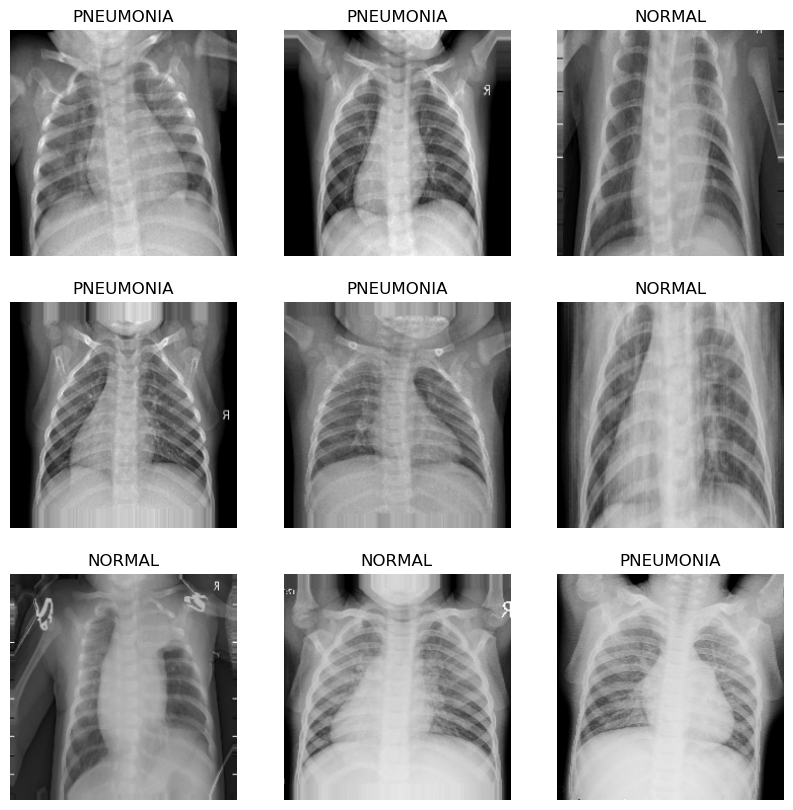

In [5]:
plt.figure(figsize=(10,10))
for i in range(9):
    img, label = next(train_data)
    plt.subplot(3,3,i+1)
    plt.imshow(img[0])
    plt.title("PNEUMONIA" if label[0]==0 else "NORMAL")
    plt.axis("off")
plt.show()


3. TRANSFER LEARNING MODEL (VGG16)

In [6]:
base = VGG16(weights="imagenet", include_top=False,
             input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

for layer in base.layers:
    layer.trainable = False

model = Sequential([
    base,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(0.0001),
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

4. TRAIN MODEL

In [7]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)


Epoch 1/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - accuracy: 0.9096 - loss: 0.2113 - val_accuracy: 0.7500 - val_loss: 0.4176
Epoch 2/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.9501 - loss: 0.1404 - val_accuracy: 0.7500 - val_loss: 0.2603
Epoch 3/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9555 - loss: 0.1181 - val_accuracy: 0.8750 - val_loss: 0.1967
Epoch 4/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.9545 - loss: 0.1183 - val_accuracy: 0.9375 - val_loss: 0.1661
Epoch 5/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9516 - loss: 0.1193 - val_accuracy: 0.9375 - val_loss: 0.1830
Epoch 6/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.9641 - loss: 0.0926 - val_accuracy: 1.0000 - val_loss: 0.1569
Epoch 7/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9625 - loss: 0.1047 - val_accuracy: 0.7500 - val_loss: 0.3157
Epoch 8/10
164/164 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.9620 - loss: 0.0950 - val_accu

5. PLOT ACCURACY & LOSS

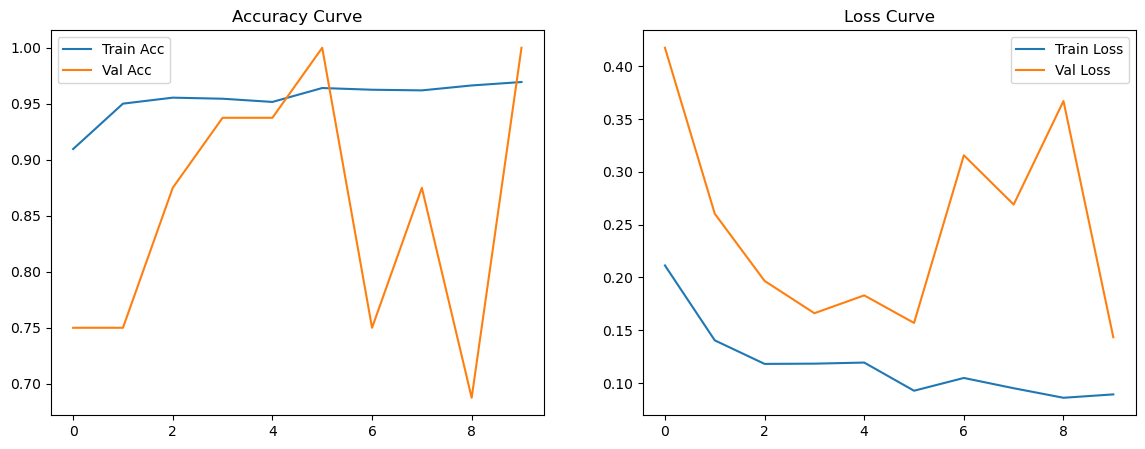

In [8]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label="Train Acc")
plt.plot(history.history['val_accuracy'], label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.show()


6. PREDICTIONS ON TEST SET

In [9]:
y_true = test_data.classes
pred = model.predict(test_data)
pred_binary = (pred >= 0.5).astype(int)


20/20 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step


7. CONFUSION MATRIX

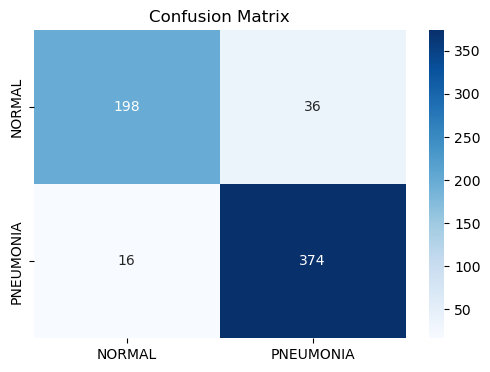

              precision    recall  f1-score   support

           0       0.93      0.85      0.88       234
           1       0.91      0.96      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.92      0.92      0.92       624



In [10]:
cm = confusion_matrix(y_true, pred_binary)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NORMAL","PNEUMONIA"],
            yticklabels=["NORMAL","PNEUMONIA"])
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, pred_binary))


8. PRECISION–RECALL CURVE

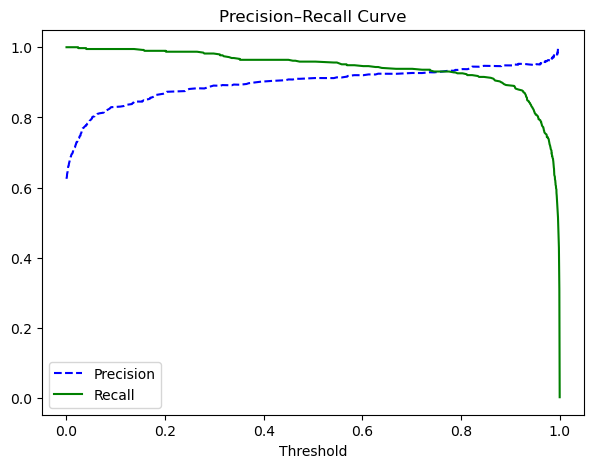

In [11]:
prec, rec, thresholds = precision_recall_curve(y_true, pred)

plt.figure(figsize=(7,5))
plt.plot(thresholds, prec[:-1], "b--", label="Precision")
plt.plot(thresholds, rec[:-1], "g-", label="Recall")
plt.title("Precision–Recall Curve")
plt.xlabel("Threshold")
plt.legend()
plt.show()


9. ROC CURVE

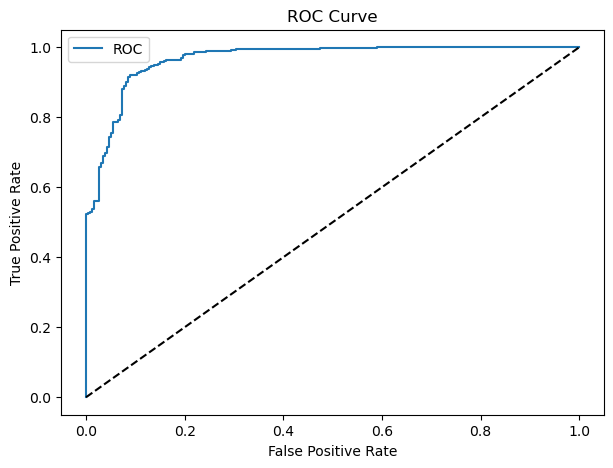

In [12]:
fpr, tpr, thresh = roc_curve(y_true, pred)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="ROC")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


10. BEST THRESHOLD BASED ON PRECISION ≥ 0.80

In [13]:
target_precision = 0.80
best_thresh = thresholds[np.argmax(prec[:-1] >= target_precision)]
print("Selected Threshold =", best_thresh)

adjusted_pred = (pred >= best_thresh).astype(int)

print("Accuracy :", accuracy_score(y_true, adjusted_pred))
print("Precision:", precision_score(y_true, adjusted_pred))
print("Recall   :", recall_score(y_true, adjusted_pred))


Selected Threshold = 0.052075867
Accuracy : 0.8413461538461539
Precision: 0.8
Recall   : 0.9948717948717949


11. DISPLAY 25 TEST IMAGES WITH PREDICTED LABELS

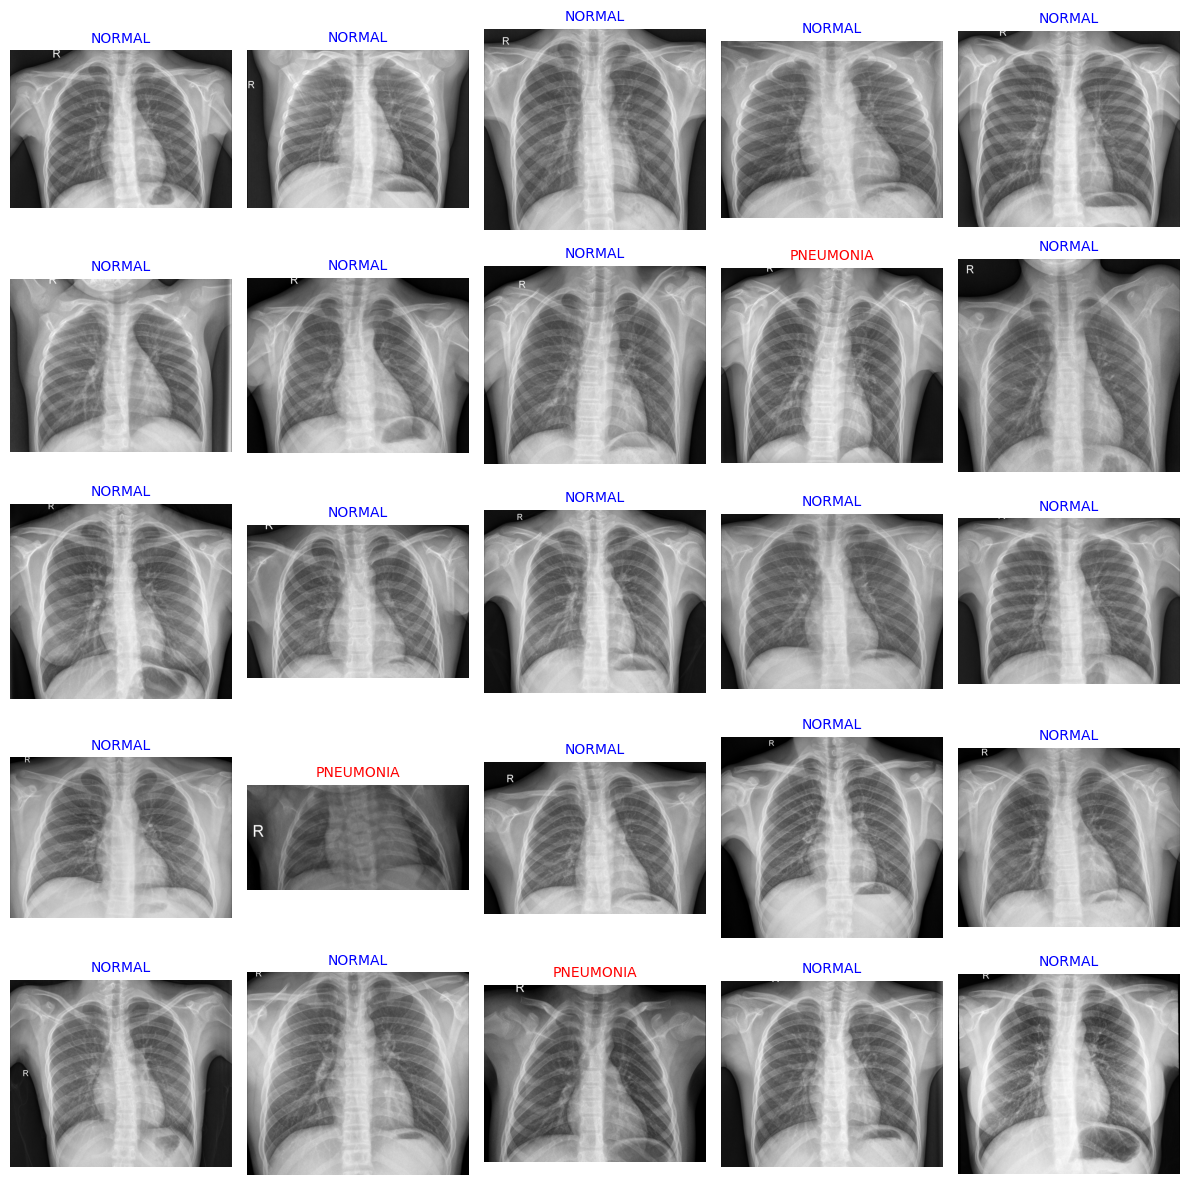

In [17]:
plt.figure(figsize=(12,12))
images = test_data.filepaths

for i in range(25):
    img = cv2.imread(images[i])
    img_resized = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

    # Convert probability to class
    pred_label = 1 if adjusted_pred[i][0] > 0.5 else 0
    true_label = y_true[i]

    plt.subplot(5,5,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    color = "blue" if pred_label == true_label else "red"
    label = "NORMAL" if pred_label == 0 else "PNEUMONIA"

    plt.title(label, color=color, fontsize=10)

plt.tight_layout()
plt.show()


12. SINGLE IMAGE TESTING FUNCTION

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


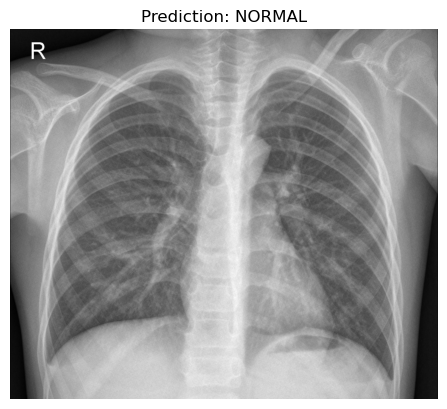

In [24]:
def test_single_image(path):
    img = cv2.imread(path)
    img_resized = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img_norm = img_resized / 255.0
    img_norm = np.expand_dims(img_norm, 0)

    pred = model.predict(img_norm)[0][0]

    # FIX: reverse mapping
    label = "NORMAL" if pred < 0.5 else "PNEUMONIA"

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {label}")
    plt.axis("off")
    plt.show()
def test_single_image(path):
    img = cv2.imread(path)
    img_resized = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img_norm = img_resized / 255.0
    img_norm = np.expand_dims(img_norm, 0)

    pred = model.predict(img_norm)[0][0]

    # FIX: reverse mapping
    label = "NORMAL" if pred < 0.5 else "PNEUMONIA"

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Prediction: {label}")
    plt.axis("off")
    plt.show()
test_single_image(r"C:\Users\DIKSH\OneDrive\Desktop\Projects\Pneumonia detection using DL\chest_xray\test\NORMAL\IM-0037-0001.jpeg")

13. SAVE MODEL

In [26]:
model.save("VGG16_pneumonia_TL_complete.h5")